# Multimodalidade com SDK OpenAI + SDK Gemini

Este notebook mostra, como enviar **texto + imagem** usando os SDKs oficiais:
- `openai` (OpenAI)
- `google-genai` (Gemini)

In [1]:
%pip install -q openai google-genai python-dotenv pillow ipywidgets

Note: you may need to restart the kernel to use updated packages.


## Configuração

Variáveis necessárias:
- `OPENAI_API_KEY`
- `GEMINI_API_KEY`

Exemplo de `.env`:

```bash
OPENAI_API_KEY=...
GEMINI_API_KEY=...
```

In [1]:
import base64
import mimetypes
import os
from pathlib import Path

from dotenv import load_dotenv
from PIL import Image
from openai import OpenAI
from google import genai
from google.genai import types
import ipywidgets as widgets
from IPython.display import display

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY não encontrada.")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY não encontrada.")

## Escolha da imagem (botão de upload)

Execute a célula abaixo e clique em **Upload** para anexar uma imagem (`jpg`, `jpeg` ou `png`).

In [2]:
uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Anexar imagem")
display(uploader)

FileUpload(value=(), accept='image/*', description='Anexar imagem')

In [3]:
def _extrair_primeiro_upload(widget):
    valor = widget.value
    if not valor:
        return None

    if isinstance(valor, dict):
        nome, item = next(iter(valor.items()))
        conteudo = item.get("content")
        mime = item.get("type") or mimetypes.guess_type(nome)[0] or "image/jpeg"
        if hasattr(conteudo, "tobytes"):
            conteudo = conteudo.tobytes()
        else:
            conteudo = bytes(conteudo)
        return nome, mime, conteudo

    item = valor[0]
    nome = item.get("name", "upload_image")
    mime = item.get("type") or mimetypes.guess_type(nome)[0] or "image/jpeg"
    conteudo = item.get("content")
    if hasattr(conteudo, "tobytes"):
        conteudo = conteudo.tobytes()
    else:
        conteudo = bytes(conteudo)
    return nome, mime, conteudo

upload = _extrair_primeiro_upload(uploader)

nome_arquivo, mime_type, imagem_bytes = upload
print(f"Imagem carregada via upload: {nome_arquivo} ({mime_type})")

imagem_b64 = base64.b64encode(imagem_bytes).decode("utf-8")
data_url = f"data:{mime_type};base64,{imagem_b64}"

Imagem carregada via upload: Captura de tela de 2026-03-05 22-23-06.png (image/png)


Imagem em uso: formato=PNG, tamanho=(1606, 724), modo=RGBA, mime=image/png


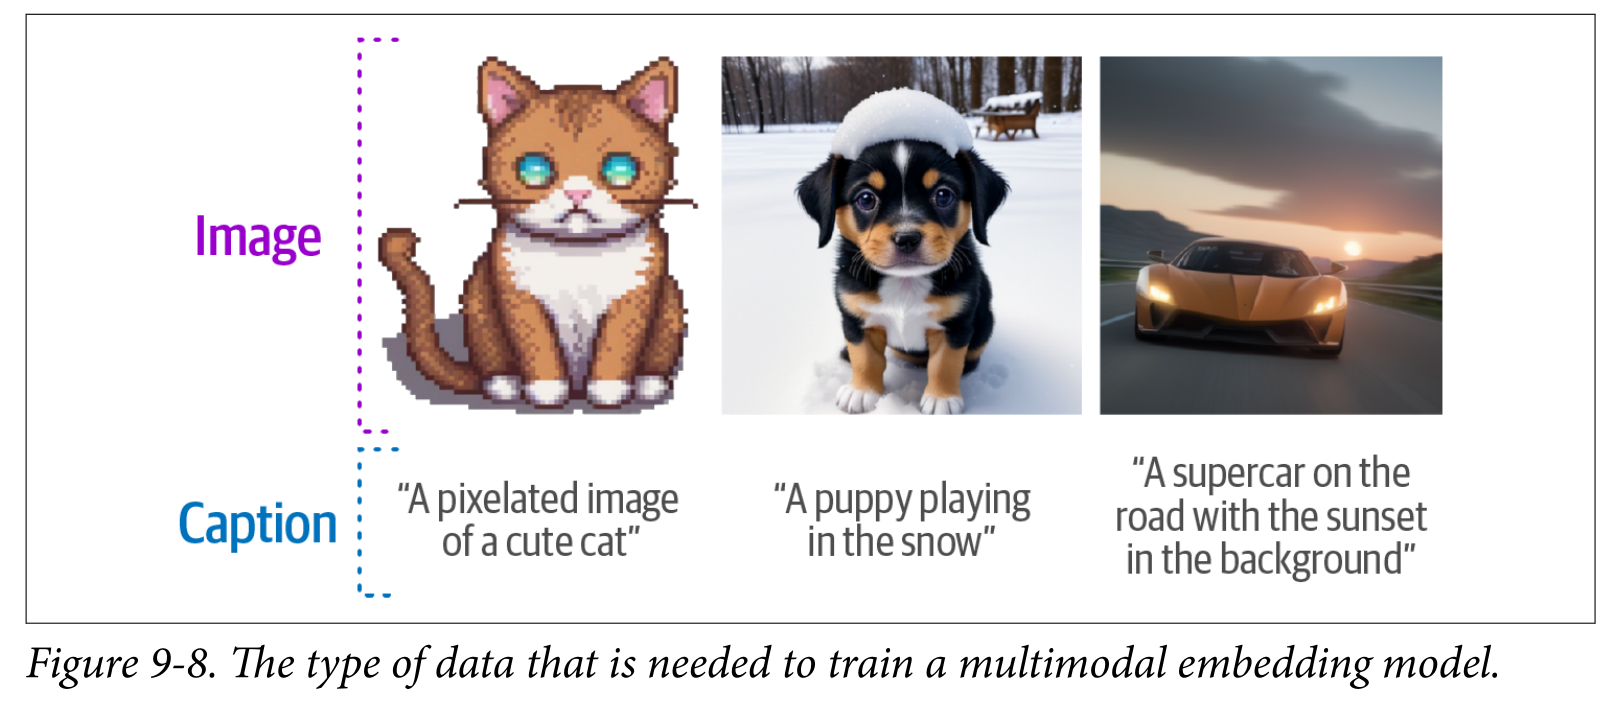

In [ ]:
# Pré-visualização explícita da imagem usada nas chamadas
from io import BytesIO
from IPython.display import display

img_preview = Image.open(BytesIO(imagem_bytes))
print(f"Imagem em uso: formato={img_preview.format}, tamanho={img_preview.size}, modo={img_preview.mode}, mime={mime_type}")
display(img_preview)

## 1) OpenAI com SDK oficial (`openai`)

Aqui usamos `client.responses.create(...)` com conteúdo multimodal.

In [5]:
openai_client = OpenAI(api_key=OPENAI_API_KEY)

resp_openai = openai_client.responses.create(
    model="gpt-5-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "Descreva a imagem em 5 tópicos."},
                {"type": "input_image", "image_url": data_url},
            ],
        }
    ],
)

print(resp_openai.output_text)

- Composição: três pares lado a lado de imagem + legenda, organizados horizontalmente num quadro.
- Esquerda: arte pixelada de um gato fofo (tons marrons e branco) com a legenda "A pixelated image of a cute cat".
- Centro: filhote de cachorro sentado na neve (olhos grandes e expressão curiosa), legenda "A puppy playing in the snow".
- Direita: um supercarro laranja em movimento numa estrada ao pôr do sol, legenda "A supercar on the road with the sunset in the background".
- Elementos de anotação: rótulos coloridos à esquerda indicando "Image" (roxo) e "Caption" (azul) com colchetes pontilhados, e legenda de figura embaixo explicando que é o tipo de dado necessário para treinar um modelo de embedding multimodal.


## 2) Gemini com SDK oficial (`google-genai`)

Aqui usamos `client.models.generate_content(...)` com texto + `Part.from_bytes`.

In [6]:
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

resp_gemini = gemini_client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        "Descreva a imagem em 5 tópicos.",
        types.Part.from_bytes(data=imagem_bytes, mime_type=mime_type),
    ],
)

print(resp_gemini.text)

Aqui estão 5 tópicos para descrever a imagem:

1.  **Propósito da Ilustração:** A imagem, intitulada "Figure 9-8", demonstra o tipo de dados (pares de imagem e legenda) necessários para treinar um modelo de embedding multimodal, que associa informações visuais a descrições textuais.
2.  **Estrutura dos Dados:** Claramente dividida em duas seções rotuladas "Image" (em roxo) e "Caption" (em azul), a figura apresenta três exemplos distintos, onde cada imagem visual é diretamente conectada à sua descrição textual correspondente por linhas pontilhadas.
3.  **Primeiro Par (Gato Pixelizado):** O primeiro exemplo exibe uma imagem pixelizada de um gato fofo, com pelos marrons e brancos, bigodes finos e olhos grandes e brilhantes de cor ciano, emparelhada com a legenda "A pixelated image of a cute cat".
4.  **Segundo Par (Filhote na Neve):** O segundo par mostra um filhote de cachorro preto, branco e marrom, sentado em um ambiente coberto de neve, com uma pequena porção de neve em cima de sua ca